In [1]:
import pandas as pd

reviews_df = pd.read_csv('iclr-2026-reviews.csv')
raw_submission_df = pd.read_parquet('../iclr-dataset/data/iclr26v1.parquet')

reviews_df['abstract'] = ''
reviews_df['labels'] = ''

for item in reviews_df.itertuples():
    submission_id = item.submission_id
    raw_item = raw_submission_df[raw_submission_df['id'] == submission_id]
    
    if not raw_item.empty:
        # Add abstract and labels
        reviews_df.at[item.Index, 'abstract'] = raw_item['abstract'].values[0]
        reviews_df.at[item.Index, 'labels'] = raw_item['labels'].values[0]



llm_df = reviews_df[reviews_df['editlens_prediction'] == "Fully AI-generated"]
human_df = reviews_df[reviews_df['editlens_prediction'] != "Fully human-written"]

know_distill_reviews_df = reviews_df[reviews_df['labels'].str.contains('knowledge distillation', na=False)]
# optimization_reviews_df = optimization_reviews_df[

In [93]:
reviews_df['labels'].unique()

array(['unlabeled', 'diffusion models', 'LLMs', 'adversarial', 'RL',
       'language models', 'CNNs', 'interpretability',
       'continual learning', 'time series', 'vision-language models',
       'graphs', 'safety', 'knowledge distillation', 'compression',
       'autonomous driving', 'optimization', 'explainability',
       'imitation learning', 'pruning', 'multi-agent RL', 'GANs',
       'self-supervised learning', 'PDEs', 'object detection',
       'robustness', 'out-of-distribution', 'privacy', 'alignment',
       'transformers', 'clustering', 'RNNs', 'code generation',
       'active learning', 'semi-supervised learning',
       'federated learning', 'ViTs', '3D scenes', 'knowledge graphs',
       'autoencoders', 'causality', 'optimal transport',
       'anomaly detection', 'in-context learning', 'fairness',
       'offline RL', 'transfer learning', 'neuroscience', 'meta learning',
       'molecules', 'multi-task learning', 'model-based RL',
       'neural architecture search'

In [ ]:
# know_distill_human_df = know_distill_reviews_df[know_distill_reviews_df['editlens_prediction'] == "Fully human-written"]
# know_distill_ai_df = know_distill_reviews_df[know_distill_reviews_df['editlens_prediction'] == "Fully AI-generated"]

# both_submissions = set(know_distill_human_df['submission_id']).intersection(set(know_distill_ai_df['submission_id']))

# # select 30 random submission ids from both_submissions
# # both_submissions = random.sample(list(both_submissions), 30)

# both_df = know_distill_reviews_df[know_distill_reviews_df['submission_id'].isin(both_submissions)]

# # only pick one fully human-written and one fully AI-generated review per submission

# both_human_df = both_df[both_df['editlens_prediction'] == "Fully human-written"]
# both_human_df = both_human_df.groupby('submission_id').head(1)
# both_ai_df = both_df[both_df['editlens_prediction'] == "Fully AI-generated"]
# both_ai_df = both_ai_df.groupby('submission_id').head(1)

In [ ]:
# len(both_submissions)

47

In [ ]:
from openai import OpenAI
import json
import os
from tqdm import tqdm

# os.environ["OPENAI_API_KEY"] = secrets["OPENAI_API_KEY"]

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=secrets["OPENROUTER_API_KEY"],
)

def create_strength_and_weakness_categories(review_texts):
    """
    Use GPT-4o to create consistent strength and weakness categories from multiple reviews.
    """
    prompt = f"""Analyze the following {len(review_texts)} peer reviews and create a set of consistent categories for strengths and weaknesses.

    Reviews (one per line, separated by "---"):
{chr(10).join([f"REVIEW {i+1}:{chr(10)}{text}{chr(10)}---" for i, text in enumerate(review_texts)])}
    Return your response as a JSON object with two arrays: "strength_categories" and "weakness_categories".
    Example:
    {{
        "strength_categories": ["Clarity", "Novelty", "Strong Results"],
        "weakness_categories": ["Lack of Clarity", "Insufficient Experiments", "Outdated Methods"]
        "definitions": {{
            "Clarity": "The paper is well-written and easy to understand.",
            "Lack of Clarity": "The paper is difficult to follow and poorly organized.",
            "Novelty": "The paper presents new and original ideas.",
            "Insufficient Experiments": "The experiments do not adequately support the claims made in the paper.",
            "Strong Results": "The results are compelling and demonstrate the effectiveness of the proposed method.",
            "Outdated Methods": "The methods used are not state-of-the-art and do not reflect recent advancements in the field."
        }}
    }}      
    """
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=1
    )
    print(response.choices[0].message.content)
    try:
        result = json.loads(response.choices[0].message.content.strip('`').strip('json').strip())
        return result
    except json.JSONDecodeError:
        return {"strength_categories": [], "weakness_categories": []}
# Create consistent categories

# run in batches 
# strength_categories_set = set()
# weakness_categories_set = set()
# for i in tqdm(range(0, len(know_distill_reviews_df), 20)):
#     batch_reviews = know_distill_reviews_df['review_text'].tolist()[i:i+20]
#     categories = create_strength_and_weakness_categories(batch_reviews)
#     # Save categories to JSON
#     # add to a set 
#     strength_categories_set.update(categories.get("strength_categories", []))
#     weakness_categories_set.update(categories.get("weakness_categories", []))


    


In [3]:
def reduce_redundant_categories(categories):
    """
    Reduce redundant categories by merging similar ones.
    """
    # Simple heuristic: lowercase and strip spaces
    prompt = f"""Given the following list of categories, reduce redundancy by merging similar ones. Return a JSON array of unique categories. 
    with a maximum of 15 categories. Do NOT provide more than 15. 

    Give a description of the categories and make sure they are distinct, e.g. don't include both "Clarity" and "Motivation Clarity".
Categories:
{json.dumps(categories, indent=4)}
Example:
{{
    "reduced_categories": ["Clarity", "Novelty", "Strong Results", "Insufficient Experiments", "Outdated Methods"]
    "definitions": {{
        "Clarity": "How clear and understandable the paper is.",
        "Novelty": "The originality and innovativeness of the research.",
        "Strong Results": "The robustness and significance of the experimental results.",
        "Insufficient Experiments": "Lack of adequate experimental validation.",
        "Outdated Methods": "Use of methods that are no longer state-of-the-art."   
    }}
}}
    """
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=1
    )
    print(response.choices[0].message.content)
    try:
        result = json.loads(response.choices[0].message.content.strip('`').strip('json').strip())
        return result.get("reduced_categories", [])
    except json.JSONDecodeError:
        return categories   

# reduced_strength_categories = reduce_redundant_categories(list(strength_categories_set))
# reduced_weakness_categories = reduce_redundant_categories(list(weakness_categories_set))
# # Save final categories to JSON
# final_categories = {
#     "strength_categories": reduced_strength_categories,
#     "weakness_categories": reduced_weakness_categories
# } 
# with open('know_distill_review_categories.json', 'w') as f:
#     json.dump(final_categories, f, indent=4)

In [ ]:
from openai import OpenAI
import json
import os
from tqdm import tqdm
from pathlib import Path

OUT_DIR = Path("out_pro"); OUT_DIR.mkdir(exist_ok=True)

os.environ["OPENAI_API_KEY"] = secrets["OPENAI_API_KEY"]

client = OpenAI()

def extract_strengths_weaknesses(review_text: str, strength_categories, weakness_categories) -> dict:
    """
    Use Claude as a judge to extract top 3 strengths and weaknesses from a review.
    """
    
    prompt = f"""Analyze the following peer review and extract the key points.

    Review:
    {review_text}

    Please identify:
    1. Top 3 strengths mentioned in the review
    2. Top 3 weaknesses mentioned in the review

    Return your response as a JSON object with the following structure:
    {{
        "strengths": ["strength 1", "strength 2", "strength 3"],
        "weaknesses": ["weakness 1", "weakness 2", "weakness 3"]
    }}

    You make pick from these strengths and weaknesses categories: 

    Strengths: 
    {json.dumps(strength_categories, indent=4)}
    
    Weaknesses:
    {json.dumps(weakness_categories, indent=4)}

    Do NOT invent strengths or weaknesses that are not in the above categories, and do not mention anything not in the review.

    Only return the JSON object, no additional text."""

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=1
    )
    
    try:
        result = json.loads(response.choices[0].message.content.strip('`').strip('json').strip())
        return result
    except json.JSONDecodeError:
        return {"strengths": [], "weaknesses": []}

# Process both_human_df
# print("Processing human-written reviews...")
# human_results = []
# for idx, row in tqdm(both_human_df.iterrows()):
#     result = extract_strengths_weaknesses(row['review_text'], reduced_strength_categories, reduced_weakness_categories)
#     result['review_id'] = row['review_id']
#     result['submission_id'] = row['submission_id']
#     result['type'] = 'human'
#     result['review_text'] = row['review_text']
#     human_results.append(result)

# # Process both_ai_df
# print("\nProcessing AI-generated reviews...")
# ai_results = []
# for idx,row in tqdm(both_ai_df.iterrows()):
#     result = extract_strengths_weaknesses(row['review_text'], reduced_strength_categories, reduced_weakness_categories)
#     result['review_id'] = row['review_id']
#     result['submission_id'] = row['submission_id']
#     result['type'] = 'ai'
#     result['review_text'] = row['review_text']
#     ai_results.append(result)

# # Combine results into dataframe
# results_df = pd.DataFrame(human_results + ai_results)
# results_df.to_csv(OUT_DIR / "strengths_weaknesses_from_automated.csv", index=False)
# print(f"\nResults saved to {OUT_DIR / 'strengths_weaknesses_from_automated.csv'}")
# print(results_df)

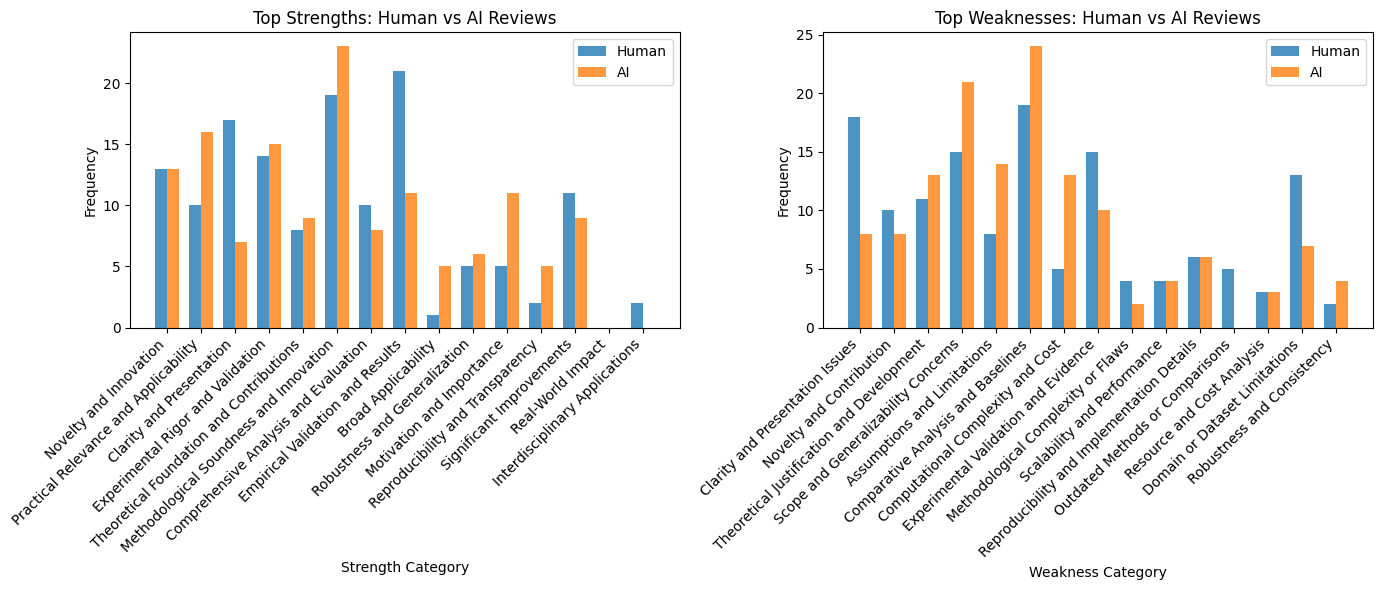

In [24]:
from collections import defaultdict
import numpy as np

import matplotlib.pyplot as plt

# Extract strengths and weaknesses by type
ai_strengths = defaultdict(int)
ai_weaknesses = defaultdict(int)
human_strengths = defaultdict(int)
human_weaknesses = defaultdict(int)

for _, row in results_df.iterrows():
    strengths = row['strengths'] if isinstance(row['strengths'], list) else []
    weaknesses = row['weaknesses'] if isinstance(row['weaknesses'], list) else []
    
    if row['type'] == 'ai':
        for s in strengths:
            ai_strengths[s] += 1
        for w in weaknesses:
            ai_weaknesses[w] += 1
    else:
        for s in strengths:
            human_strengths[s] += 1
        for w in weaknesses:
            human_weaknesses[w] += 1

# Get top categories
top_strength_cats = reduced_strength_categories
top_weakness_cats = reduced_weakness_categories

# Prepare data
strength_ai = [ai_strengths.get(cat, 0) for cat in top_strength_cats]
strength_human = [human_strengths.get(cat, 0) for cat in top_strength_cats]
weakness_ai = [ai_weaknesses.get(cat, 0) for cat in top_weakness_cats]
weakness_human = [human_weaknesses.get(cat, 0) for cat in top_weakness_cats]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(top_strength_cats))
width = 0.35

ax1.bar(x - width/2, strength_human, width, label='Human', alpha=0.8)
ax1.bar(x + width/2, strength_ai, width, label='AI', alpha=0.8)
ax1.set_xlabel('Strength Category')
ax1.set_ylabel('Frequency')
ax1.set_title('Top Strengths: Human vs AI Reviews')
ax1.set_xticks(x)
ax1.set_xticklabels(top_strength_cats, rotation=45, ha='right')
ax1.legend()

x2 = np.arange(len(top_weakness_cats))
ax2.bar(x2 - width/2, weakness_human, width, label='Human', alpha=0.8)
ax2.bar(x2 + width/2, weakness_ai, width, label='AI', alpha=0.8)
ax2.set_xlabel('Weakness Category')
ax2.set_ylabel('Frequency')
ax2.set_title('Top Weaknesses: Human vs AI Reviews')
ax2.set_xticks(x2)
ax2.set_xticklabels(top_weakness_cats, rotation=45, ha='right')
ax2.legend()
plt.savefig('strengths_weaknesses_comparison.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [25]:
# create a metric that reflects the "spread" of strengths and weaknesses mentioned in reviews
def calculate_spread_metric(strengths_dict, weaknesses_dict):
    """
    Calculate a spread metric based on the distribution of strengths and weaknesses.
    Higher values indicate a more diverse set of strengths/weaknesses mentioned.
    """
    def spread(counts):
        total = sum(counts)
        if total == 0:
            return 0
        proportions = [count / total for count in counts if count > 0]
        return -sum(p * np.log(p) for p in proportions)  # Shannon entropy

    strength_counts = list(strengths_dict.values())
    weakness_counts = list(weaknesses_dict.values())
    
    strength_spread = spread(strength_counts)
    weakness_spread = spread(weakness_counts)
    
    return strength_spread, weakness_spread
ai_strength_spread, ai_weakness_spread = calculate_spread_metric(ai_strengths, ai_weaknesses)
human_strength_spread, human_weakness_spread = calculate_spread_metric(human_strengths, human_weaknesses)

In [26]:
ai_strength_spread, ai_weakness_spread, human_strength_spread, human_weakness_spread

(np.float64(2.5384871322512783),
 np.float64(2.535390538599353),
 np.float64(2.418078808725277),
 np.float64(2.527162864531745))

In [5]:
def perform_analysis_for_topic(topic_name, reviews_df):
    topic_reviews_df = reviews_df[reviews_df['labels'].str.contains(topic_name, na=False)]
    
    topic_human_df = topic_reviews_df[topic_reviews_df['editlens_prediction'] == "Fully human-written"]
    topic_ai_df = topic_reviews_df[topic_reviews_df['editlens_prediction'] == "Fully AI-generated"]
    
    both_submissions = set(topic_human_df['submission_id']).intersection(set(topic_ai_df['submission_id']))
    
    topic_both_df = topic_reviews_df[topic_reviews_df['submission_id'].isin(both_submissions)]
    
    # only pick one fully human-written and one fully AI-generated review per submission
    topic_both_human_df = topic_both_df[topic_both_df['editlens_prediction'] == "Fully human-written"]
    topic_both_human_df = topic_both_human_df.groupby('submission_id').head(1)
    topic_both_ai_df = topic_both_df[topic_both_df['editlens_prediction'] == "Fully AI-generated"]
    topic_both_ai_df = topic_both_ai_df.groupby('submission_id').head(1)

    strength_categories_set = set()
    weakness_categories_set = set()
    for i in tqdm(range(0, len(topic_both_human_df[:1000]), 20)):
        batch_reviews = topic_both_human_df['review_text'].tolist()[i:i+20]
        categories = create_strength_and_weakness_categories(batch_reviews)
        # Save categories to JSON
        # add to a set 
        strength_categories_set.update(categories.get("strength_categories", []))
        weakness_categories_set.update(categories.get("weakness_categories", []))

    reduced_strength_categories = reduce_redundant_categories(list(strength_categories_set))
    reduced_weakness_categories = reduce_redundant_categories(list(weakness_categories_set))

    print("Processing human-written reviews...")
    human_results = []
    for idx, row in tqdm(topic_both_human_df.iterrows()):
        result = extract_strengths_weaknesses(row['review_text'], reduced_strength_categories, reduced_weakness_categories)
        result['review_id'] = row['review_id']
        result['submission_id'] = row['submission_id']
        result['type'] = 'human'
        result['review_text'] = row['review_text']
        human_results.append(result)

    # Process topic_both_ai_df
    print("\nProcessing AI-generated reviews...")
    ai_results = []
    for idx,row in tqdm(topic_both_ai_df.iterrows()):
        result = extract_strengths_weaknesses(row['review_text'], reduced_strength_categories, reduced_weakness_categories)
        result['review_id'] = row['review_id']
        result['submission_id'] = row['submission_id']
        result['type'] = 'ai'
        result['review_text'] = row['review_text']
        ai_results.append(result)

    # Combine results into dataframe
    results_df = pd.DataFrame(human_results + ai_results)
    results_df.to_csv(OUT_DIR / f"strengths_weaknesses_from_automated_{topic_name}_1.csv", index=False)
    print(f"\nResults saved to {OUT_DIR / f'strengths_weaknesses_from_automated_{topic_name}_1.csv'}")
    return topic_both_human_df, topic_both_ai_df, results_df, reduced_strength_categories, reduced_weakness_categories
    

In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

def analyze_significance(group1_counts, group2_counts, items_per_group):
    """
    group1_counts: Dict of {category_name: count}
    group2_counts: Dict of {category_name: count}
    items_per_group: Total number of unique items in each group
    """
    # Each item has 3 categories, so the total 'n' is items * 3
    nobs = items_per_group * 3
    
    print(f"{'Category':<20} | {'G1 %':<8} | {'G2 %':<8} | {'% Change':<10} | {'P-Value':<8} | {'Sig?'}")
    print("-" * 80)

    significant_dict = {}

    for cat in group1_counts.keys():
        count1 = group1_counts[cat]
        count2 = group2_counts.get(cat, 0)
        
        # Calculate Proportions
        prop1 = count1 / nobs
        prop2 = count2 / nobs
        diff = prop2 - prop1
        
        # Z-test for proportions
        # count array = [successes in G1, successes in G2]
        # nobs array = [total trials in G1, total trials in G2]
        stat, pval = proportions_ztest([count1, count2], [nobs, nobs])
        
        is_significant = "YES" if pval < 0.05 else "no"
        
        print(f"{cat:<20} | {prop1:>7.2%} | {prop2:>7.2%} | {diff:>+9.2%} | {pval:>8.4f} | {is_significant}")
        if is_significant == "YES":
            significant_dict[cat] = {
                "group1_prop": prop1,
                "group2_prop": prop2,
                "diff": diff,
                "pval": pval
            }

    return significant_dict

In [30]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

color_human = '#1A1A1A'   # Dark gray (neutral anchor)
color_inf = '#6A5ACD'     # slateblue / periwinkle    
color_ai    = '#009E73'   # Strong blue

def visualize_results(
    results_df,
    topic_name,
    strength_categories,
    weakness_categories,
    change_threshold=0.20,
    absolute_threshold=25
):
    # Count frequencies
    ai = defaultdict(int)
    human = defaultdict(int)

    print(results_df.head())

    for _, row in results_df.iterrows():
        strengths = row['strengths'] if isinstance(row['strengths'], list) else []
        weaknesses = row['weaknesses'] if isinstance(row['weaknesses'], list) else []
        items = strengths + weaknesses

        if row['type'] == 'ai':
            for item in items:
                ai[item] += 1
        else:
            for item in items:
                human[item] += 1
    
    print(human, ai)
    
    significant_strengths = analyze_significance(human, ai, len(results_df))
    significant_weaknesses = analyze_significance(human, ai, len(results_df))

    def compute_percent_change(categories):
        changes = {}
        for cat in categories:
            h = human.get(cat, 0)
            a = ai.get(cat, 0)
            denom = max(h, 1)  # avoid divide-by-zero
            pct_change = (h - a) / denom
            changes[cat] = pct_change
        return changes

    strength_changes = compute_percent_change(significant_strengths.keys())
    weakness_changes = compute_percent_change(significant_weaknesses.keys())

    def plot_changes(ax, changes, title):
        if not changes:
            ax.set_title(title)
            ax.text(0.5, 0.5, "No significant changes",
                    ha="center", va="center", transform=ax.transAxes)
            return

        # Convert to percent and sort
        items = [(cat, val * 100) for cat, val in changes.items()]
        items.sort(key=lambda x: x[1], reverse=True)  # positive on top

        cats = [i[0] for i in items]
        values = np.array([i[1] for i in items])

        y = np.arange(len(cats))

        ax.barh(y, values, color=[color_ai if v >= 0 else color_human for v in values])
        ax.axvline(0, linestyle='--', linewidth=1)

        ax.set_yticks(y)
        ax.set_yticklabels(cats)
        ax.tick_params(axis='x', labelsize=16)
        ax.tick_params(axis='y', labelsize=16)
        ax.set_xlabel('Percent Change (AI vs Human)', fontsize=16)
        ax.set_title(title, fontsize=16)

        # Symmetric percent scale
        max_val = max(abs(values))
        ax.set_xlim(-max_val * 1.35, max_val * 1.35)

        # Put largest positive at top
        ax.invert_yaxis()

        for i, v in enumerate(values):
            ax.text(
                v + (1 if v >= 0 else -1),
                i,
                f"{v:+.0f}%",
                va="center",
                ha="left" if v >= 0 else "right",
                fontsize=11
            )


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    plot_changes(
        ax1,
        strength_changes,
        f'Significant Strength Changes ({topic_name})'
    )

    plot_changes(
        ax2,
        weakness_changes,
        f'Significant Weakness Changes ({topic_name})'
    )

    plt.tight_layout()
    plt.savefig(
        OUT_DIR / f'percent_change_diverging_{topic_name}.pdf',
        dpi=300
    )
    plt.show() 

Category             | G1 %     | G2 %     | % Change   | P-Value  | Sig?
--------------------------------------------------------------------------------
Problem Significance |   8.82% |   7.19% |    -1.63% |   0.4564 | no
Practical Impact     |   8.17% |   8.17% |    +0.00% |   1.0000 | no
Evaluation Quality   |   8.17% |   8.50% |    +0.33% |   0.8837 | no
Scope                |   4.25% |   6.21% |    +1.96% |   0.2759 | no
Benchmarking Quality |  10.46% |  12.09% |    +1.63% |   0.5228 | no
Novelty              |  13.73% |  13.07% |    -0.65% |   0.8124 | no
Interdisciplinary Approach |   1.31% |   0.65% |    -0.65% |   0.4119 | no
Clarity              |  14.38% |   7.52% |    -6.86% |   0.0066 | YES
Overclaiming         |   0.98% |   2.29% |    +1.31% |   0.2022 | no
Experimental Robustness |   9.48% |   8.82% |    -0.65% |   0.7792 | no
Generalizability     |   2.61% |   1.63% |    -0.98% |   0.4003 | no
Methodological Rigor |   8.50% |  11.44% |    +2.94% |   0.2246 | no
Scalabi

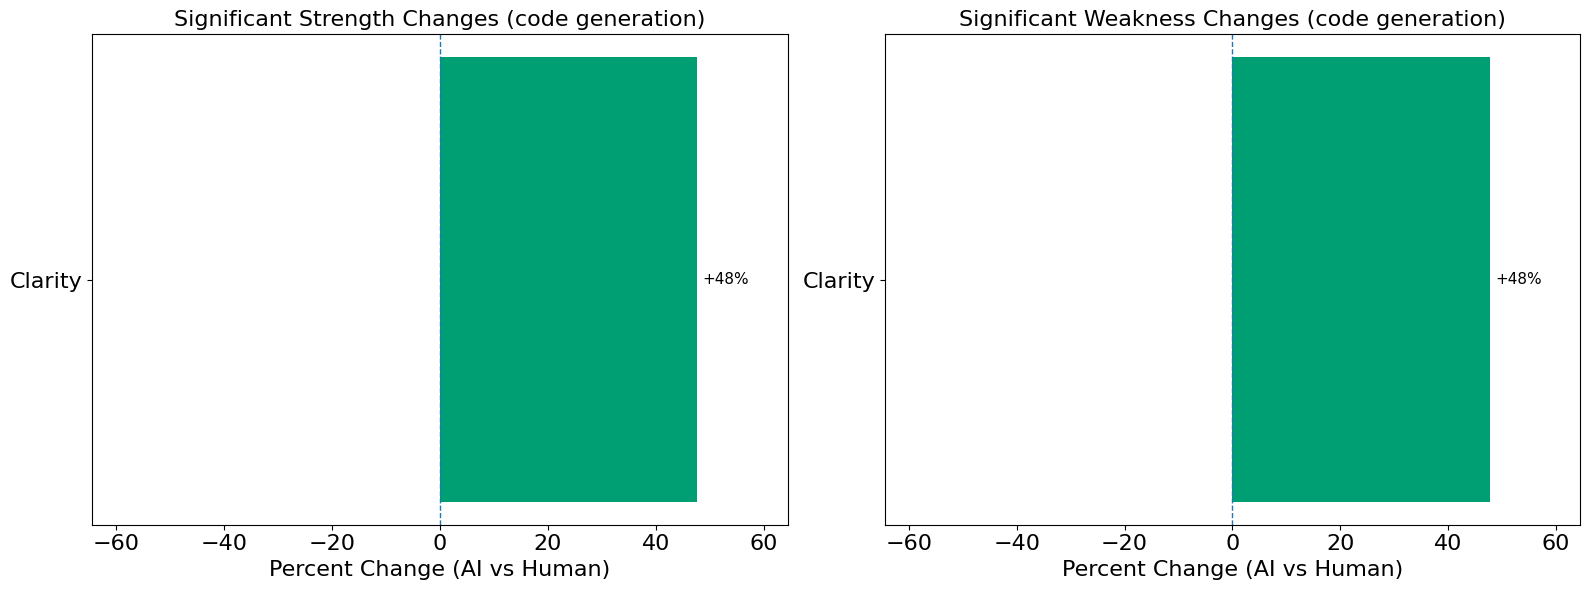

In [22]:
# human, ai, code_results, strength_categories, weakness_categories = perform_analysis_for_topic('code generation', reviews_df)
visualize_results(code_results, 'code generation', strength_categories, weakness_categories)


                                           strengths  \
0             [Clarity, Novelty, Experimental Rigor]   
1  [Novelty, Comprehensive Analysis, Practical Re...   
2  [Experimental Rigor, Empirical Evidence, Compr...   
3  [Experimental Rigor, Comprehensive Analysis, E...   
4         [Novelty, Theoretical Foundation, Clarity]   

                                          weaknesses   review_id  \
0  [Baselines and Comparisons, Experimental Rigor...  qgLhRhc4hy   
1  [Methodology Detail, Baselines and Comparisons...  b8RUuf49nR   
2  [Clarity, Theoretical Justification, Scope and...  wKafIrVjWQ   
3  [Novelty, Scope and Generalizability, Methodol...  5Q5IJpsi2t   
4  [Practical Relevance, Baselines and Comparison...  US7Jar9DAl   

  submission_id   type                                        review_text  
0    tuFRx6Ww2n  human  This paper proposes a method named Latent Sent...  
1    KeJqoEVOeY  human  This paper introduces CoLLMLight, the first fr...  
2    Ybv4qufmuG  human  Th

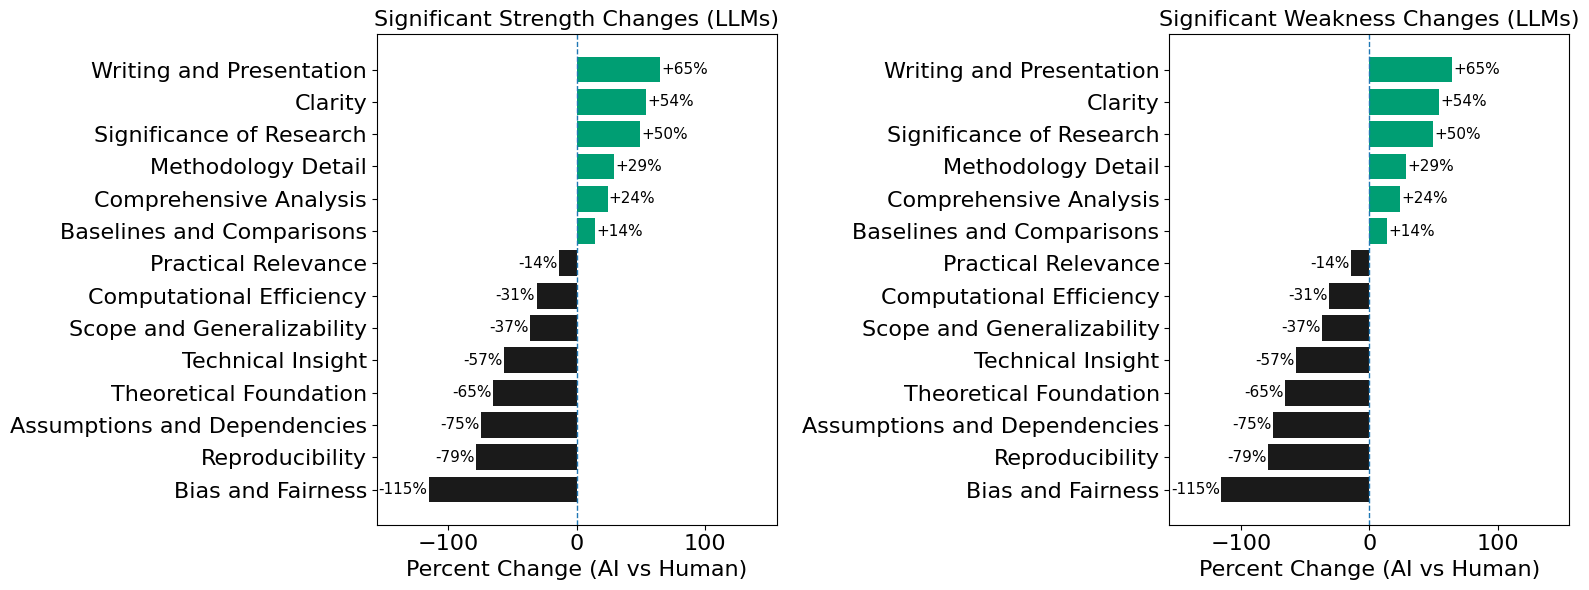

In [ ]:
import ast


strength_categories = llms_df['strengths'].explode().unique().tolist()
weakness_categories = llms_df['weaknesses'].explode().unique().tolist()
# convert strength and weakness columns from string representation of list to actual lists
llms_df['strengths'] = llms_df['strengths'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
llms_df['weaknesses'] = llms_df['weaknesses'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
visualize_results(llms_df, 'LLMs', strength_categories, weakness_categories)

In [51]:
llms_df

,strengths,weaknesses,review_id,submission_id,type,review_text
0,"['Clarity', 'Novelty', 'Experimental Rigor']","['Baselines and Comparisons', 'Experimental Ri...",qgLhRhc4hy,tuFRx6Ww2n,human,This paper proposes a method named Latent Sent...
1,"['Novelty', 'Comprehensive Analysis', 'Practic...","['Methodology Detail', 'Baselines and Comparis...",b8RUuf49nR,KeJqoEVOeY,human,"This paper introduces CoLLMLight, the first fr..."
2,"['Experimental Rigor', 'Empirical Evidence', '...","['Clarity', 'Theoretical Justification', 'Scop...",wKafIrVjWQ,Ybv4qufmuG,human,The paper studies RL training in LLM problems ...
3,"['Experimental Rigor', 'Comprehensive Analysis...","['Novelty', 'Scope and Generalizability', 'Met...",5Q5IJpsi2t,ybqL3FSOgG,human,This paper evaluates using multi-modal LLMs fo...
4,"['Novelty', 'Theoretical Foundation', 'Clarity']","['Practical Relevance', 'Baselines and Compari...",US7Jar9DAl,B3Muyi2zgo,human,This paper presents eNeRgy-GPT (NRGPT) a frame...
...,...,...,...,...,...,...
2235,"['Novelty', 'Methodological Soundness', 'Compr...","['Assumptions and Dependencies', 'Scope and Ge...",fNDHvhjUIb,tysSSTIvYM,ai,"This paper introduces VALUEFLOW, a unified fra..."
2236,"['Significance of Research', 'Methodological S...","['Evaluation Metrics', 'Scope and Generalizabi...",dlVUYsQmpy,2mXRhL4oPS,ai,This paper explores the use of model editing t...
2237,"['Novelty', 'Practical Relevance', 'Technical ...","['Methodology Detail', 'Writing and Presentati...",LRELevrmkc,1JyePezdlF,ai,The paper proposes a workload-aware LLM servin...
2238,"['Significance of Research', 'Methodological S...","['Scope and Generalizability', 'Bias and Fairn...",KcBIZGqAuD,Y7xCdFuFw7,ai,"This paper introduces HeurekaBench, a framewor..."


In [87]:
strength_categories

['Practical Application',
 'Community Contribution',
 'Strong Results',
 'Significance',
 'Clarity and Organization',
 'Thorough Experimentation',
 'Novelty',
 'Evaluation Effectiveness',
 'Methodology Clarity',
 'Methodological Innovation']

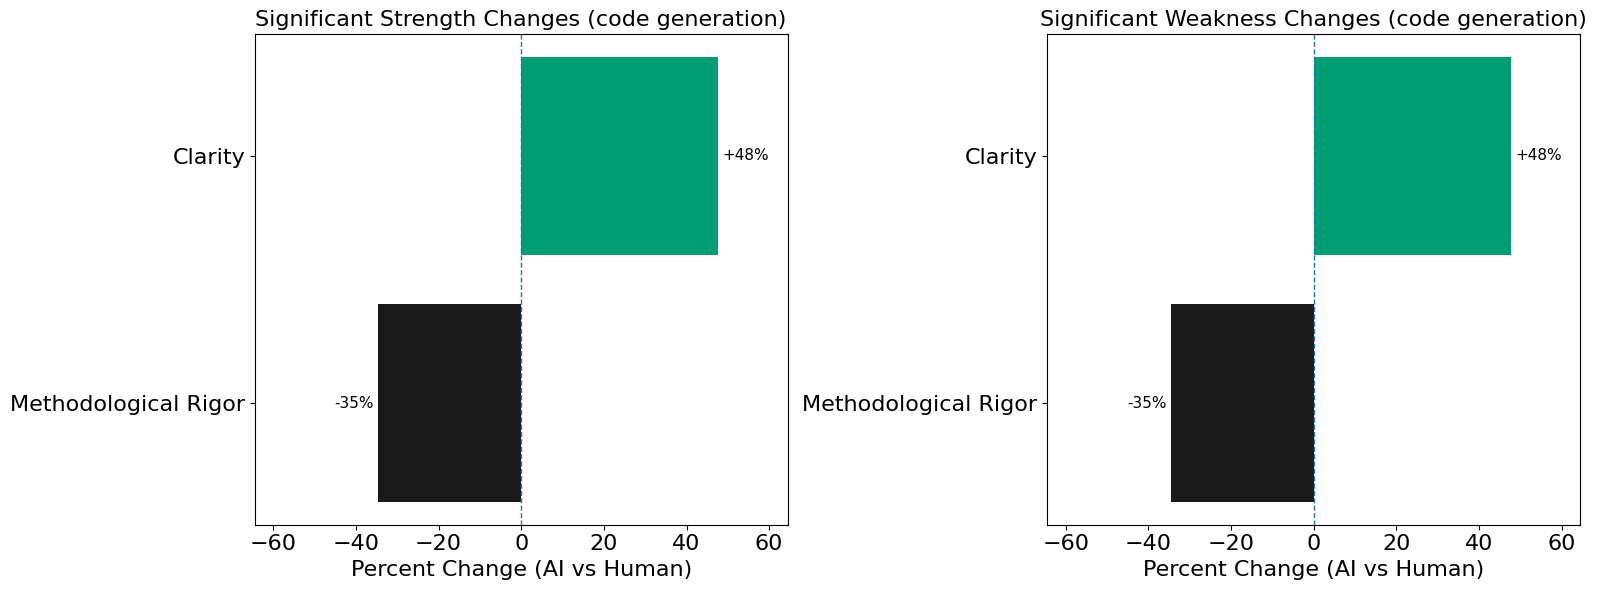

In [14]:
visualize_results(code_results, 'code generation', strength_categories, weakness_categories)

In [ ]:


# --- Example Usage ---
# Total items processed: 500 per group
# Total slots: 1500 per group
num_items = 500

g1 = {"Helpfulness": 450, "Safety": 120, "Conciseness": 300}
g2 = {"Helpfulness": 400, "Safety": 150, "Conciseness": 310}

analyze_significance(g1, g2, num_items)

Category             | G1 %     | G2 %     | % Change   | P-Value  | Sig?
--------------------------------------------------------------------------------
Helpfulness          |  30.00% |  26.67% |    -3.33% |   0.0428 | YES
Safety               |   8.00% |  10.00% |    +2.00% |   0.0556 | no
Conciseness          |  20.00% |  20.67% |    +0.67% |   0.6501 | no


{'Helpfulness': {'group1_prop': 0.3,
  'group2_prop': 0.26666666666666666,
  'diff': -0.033333333333333326,
  'pval': np.float64(0.042782715062357035)}}

 33%|███▎      | 1/3 [00:15<00:30, 15.37s/it]

```json
{
    "strength_categories": [
        "Clarity and Presentation",
        "Novelty and Innovation",
        "Strong Empirical Evidence",
        "Practical Relevance",
        "Theoretical Support",
        "Robustness and Generalization"
    ],
    "weakness_categories": [
        "Insufficient Experimental Validation",
        "Lack of Novelty",
        "Clarity and Terminology Issues",
        "Unsubstantiated Claims",
        "Outdated Comparisons",
        "Insufficient Theoretical Analysis",
        "Limited Scope and Generalization",
        "Complexity and Overhead"
    ],
    "definitions": {
        "Clarity and Presentation": "The paper is well-organized, well-written, and easy to follow. Diagrams and figures aid in understanding.",
        "Novelty and Innovation": "The paper introduces new and original ideas, concepts, or methods that contribute to the field.",
        "Strong Empirical Evidence": "The experiments are comprehensive and provide compelling support f

 67%|██████▋   | 2/3 [00:39<00:20, 20.71s/it]

```json
{
    "strength_categories": [
        "Novelty",
        "Comprehensive Experiments",
        "Clarity and Presentation",
        "Innovative Methods",
        "Strong Results",
        "Cross-Domain Generalization"
    ],
    "weakness_categories": [
        "Lack of Clarity",
        "Insufficient Experiments",
        "Limited Baseline Comparison",
        "Scalability Concerns",
        "Lack of Novelty",
        "Unclear Contribution",
        "Reliance on Assumptions",
        "Unaddressed Limitations"
    ],
    "definitions": {
        "Novelty": "The paper presents new and original ideas.",
        "Comprehensive Experiments": "The experiments are thorough and cover various aspects of the proposed method.",
        "Clarity and Presentation": "The paper is well-written and easy to understand.",
        "Innovative Methods": "The paper introduces creative and useful methods or frameworks.",
        "Strong Results": "The results convincingly demonstrate the effectivene

100%|██████████| 3/3 [00:47<00:00, 15.96s/it]

...

```json
{
    "reduced_categories": [
        "Clarity",
        "Novelty",
        "Practical Relevance",
        "Theoretical Support",
        "Sound Methodology",
        "Generalization",
        "Strong Results",
        "Robustness",
        "Comprehensive Experiments"
    ],
    "definitions": {
        "Clarity": "How clear and understandable the paper and its presentation are.",
        "Novelty": "The originality and innovativeness of the methods and ideas.",
        "Practical Relevance": "The importance and applicability of the research in real-world settings.",
        "Theoretical Support": "The extent to which the research is backed by solid theoretical foundations.",
        "Sound Methodology": "The correctness and appropriateness of the methods used in the research.",
        "Generalization": "The ability of the model or findings to apply across various domains or scenarios.",
        "Strong Results": "The robustness and significance of the experimental outcomes.",

47it [01:06,  1.42s/it]



Processing AI-generated reviews...


47it [01:05,  1.39s/it]



Results saved to out_pro/strengths_weaknesses_from_automated_knowledge distillation_1.csv


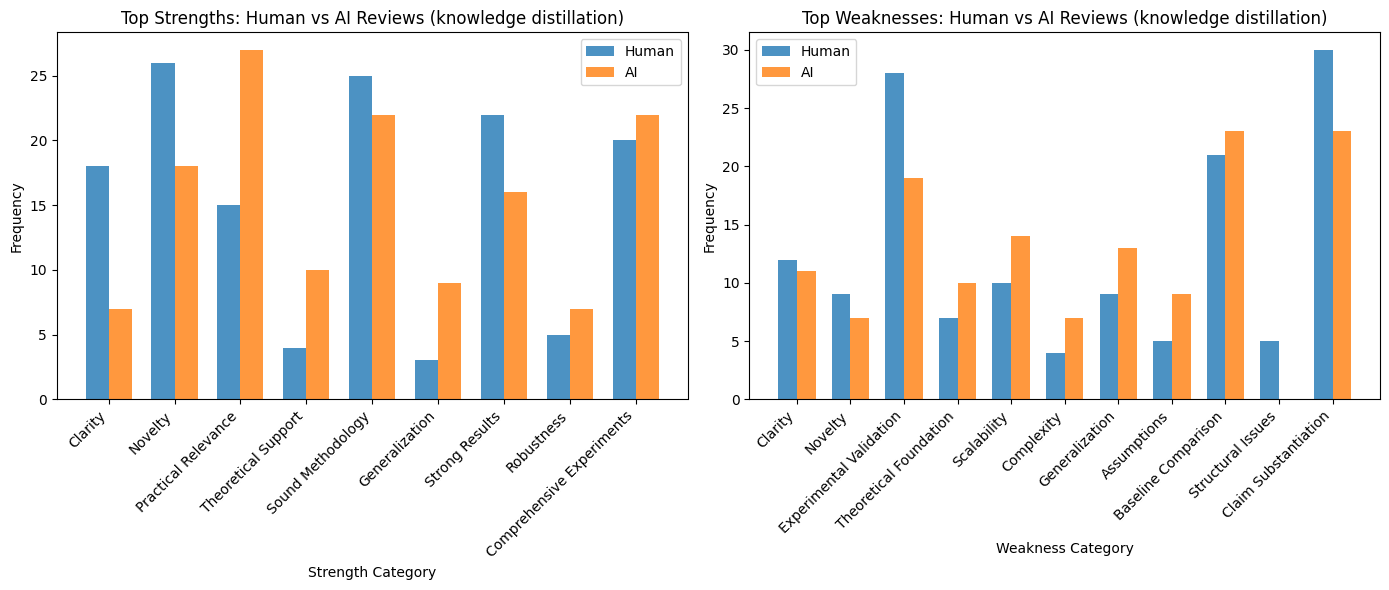

In [90]:
human, ai, results, strength_categories, weakness_categories = perform_analysis_for_topic('knowledge distillation', reviews_df)
visualize_results(results, 'knowledge distillation', strength_categories, weakness_categories)

  2%|▏         | 1/50 [00:06<05:02,  6.17s/it]

```json
{
    "strength_categories": [
        "Clarity",
        "Novelty",
        "Comprehensive Experiments",
        "Effective Results",
        "Practical Relevance",
        "Theoretical Contribution"
    ],
    "weakness_categories": [
        "Lack of Clarity",
        "Insufficient Experiments",
        "Limited Novelty",
        "Unclear Practical Impact",
        "Weak Methodological Foundation",
        "Theoretical Flaws"
    ],
    "definitions": {
        "Clarity": "The paper is well-written and easy to understand, with logical structuring of ideas.",
        "Lack of Clarity": "The paper is difficult to follow due to poor organization or unclear presentation of ideas.",
        "Novelty": "The paper presents new and original ideas that contribute to advancing the field.",
        "Limited Novelty": "The contribution of the paper is minimal or closely resembles previous works, showing little advancement.",
        "Comprehensive Experiments": "The paper includes well-

  4%|▍         | 2/50 [00:12<04:49,  6.04s/it]

```json
{
    "strength_categories": [
        "Novelty",
        "Strong Results",
        "Clear Presentation",
        "Comprehensive Evaluation",
        "Relevance",
        "Theoretical Grounding"
    ],
    "weakness_categories": [
        "Lack of Clarity",
        "Insufficient Experimentation",
        "Limited Generalizability",
        "Issues with Evaluation Metrics",
        "Lack of Novelty",
        "Implementation Details"
    ],
    "definitions": {
        "Novelty": "The work introduces new and original concepts or approaches.",
        "Strong Results": "The results convincingly demonstrate the effectiveness of the proposed method.",
        "Clear Presentation": "The paper is well-organized and easy to understand.",
        "Comprehensive Evaluation": "The paper includes thorough experiments across multiple datasets or scenarios to support its claims.",
        "Relevance": "The work addresses an important and timely problem in the field.",
        "Theoretical Gr

  6%|▌         | 3/50 [00:27<08:00, 10.22s/it]

...

```json
{
    "reduced_categories": [
        "Clarity",
        "Novelty",
        "Theoretical Foundation",
        "Experimental Rigor",
        "Practical Relevance",
        "Methodological Soundness",
        "Comprehensive Analysis",
        "Impact",
        "Real-World Application",
        "Robustness",
        "Empirical Evidence",
        "Innovation",
        "Reproducibility",
        "Technical Insight",
        "Significance of Research"
    ],
    "definitions": {
        "Clarity": "The quality of writing and presentation, ensuring the research is easy to read and understand.",
        "Novelty": "The degree of originality and innovativeness present in the research approach or findings.",
        "Theoretical Foundation": "The strength and depth of the underlying theoretical concepts and justifications.",
        "Experimental Rigor": "The thoroughness and precision applied in the design and execution of experiments.",
        "Practical Relevance": "The extent to whi

1120it [24:05,  1.29s/it]



Processing AI-generated reviews...


1120it [26:31,  1.42s/it]



Results saved to out_pro/strengths_weaknesses_from_automated_LLMs_1.csv


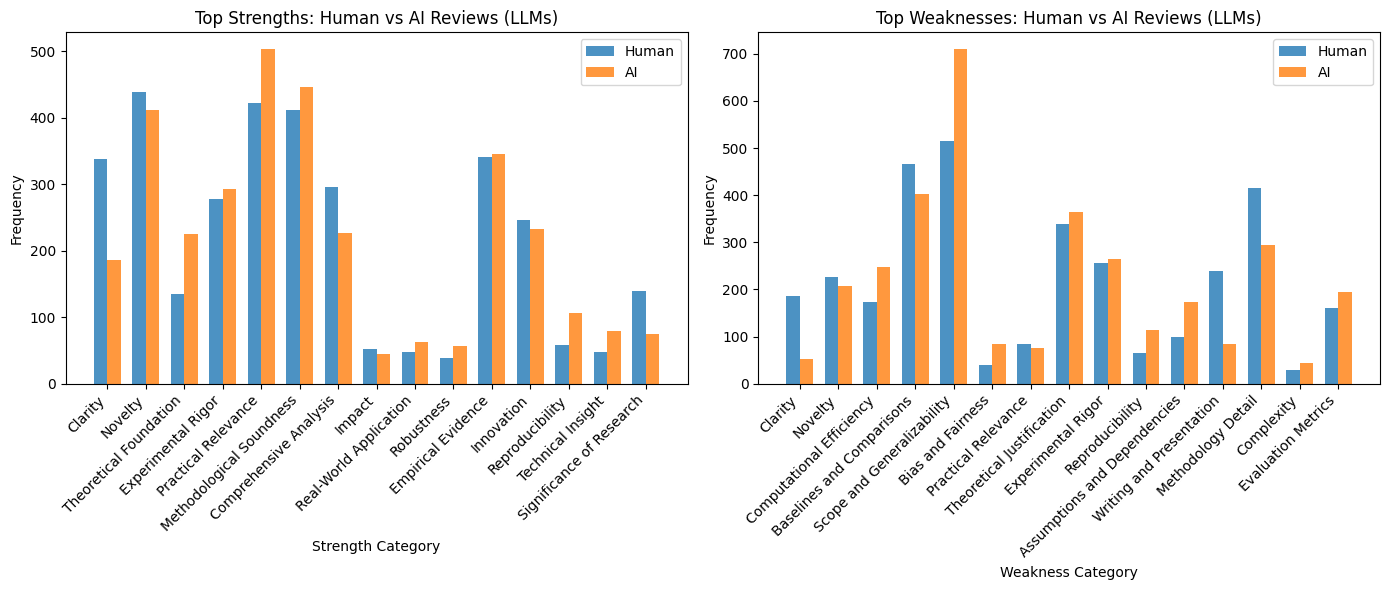

In [96]:
human, ai, results, strength_categories, weakness_categories = perform_analysis_for_topic('LLMs', reviews_df)


In [ ]:
# change the graph style of visualize_results to be a vertical bar chart, with zero difference as a vertical line in the middle
# 

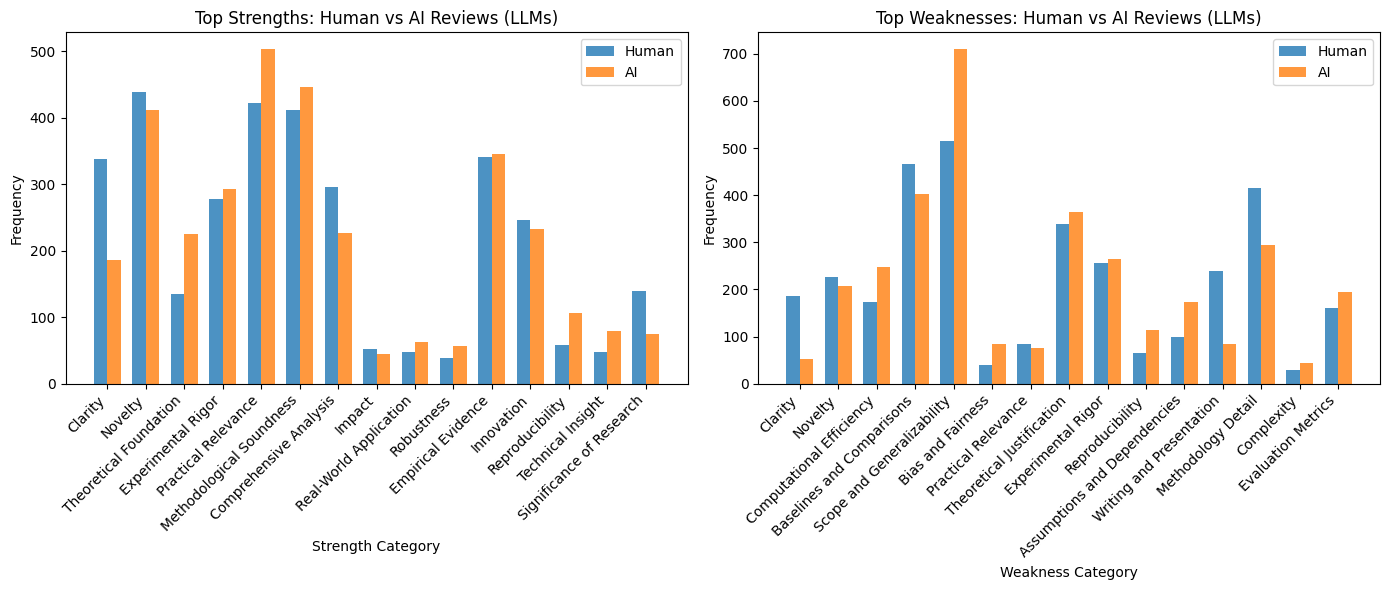

In [102]:
visualize_results(results, 'LLMs', strength_categories, weakness_categories)

In [9]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

color_human = '#1A1A1A'   # Dark gray (neutral anchor)
color_inf = '#6A5ACD'     # slateblue / periwinkle    
color_ai    = '#009E73'   # Strong blue

def visualize_results(
    results_df,
    topic_name,
    strength_categories,
    weakness_categories,
    change_threshold=0.20,
    absolute_threshold=25
):
    # Count frequencies
    ai = defaultdict(int)
    human = defaultdict(int)

    for _, row in results_df.iterrows():
        strengths = row['strengths'] if isinstance(row['strengths'], list) else []
        weaknesses = row['weaknesses'] if isinstance(row['weaknesses'], list) else []
        items = strengths + weaknesses

        if row['type'] == 'ai':
            for item in items:
                ai[item] += 1
        else:
            for item in items:
                human[item] += 1

    def compute_percent_change(categories):
        changes = {}
        for cat in categories:
            h = human.get(cat, 0)
            a = ai.get(cat, 0)
            denom = max(h, 1)  # avoid divide-by-zero
            pct_change = (h - a) / denom
            if abs(pct_change) >= change_threshold and (h - a) >= absolute_threshold:
                changes[cat] = pct_change
        return changes

    strength_changes = compute_percent_change(strength_categories)
    weakness_changes = compute_percent_change(weakness_categories)

    def plot_changes(ax, changes, title):
        if not changes:
            ax.set_title(title)
            ax.text(0.5, 0.5, "No significant changes",
                    ha="center", va="center", transform=ax.transAxes)
            return

        # Convert to percent and sort
        items = [(cat, val * 100) for cat, val in changes.items()]
        items.sort(key=lambda x: x[1], reverse=True)  # positive on top

        cats = [i[0] for i in items]
        values = np.array([i[1] for i in items])

        y = np.arange(len(cats))

        ax.barh(y, values, color=[color_ai if v >= 0 else color_human for v in values])
        ax.axvline(0, linestyle='--', linewidth=1)

        ax.set_yticks(y)
        ax.set_yticklabels(cats)
        ax.tick_params(axis='x', labelsize=16)
        ax.tick_params(axis='y', labelsize=16)
        ax.set_xlabel('Percent Change (AI vs Human)', fontsize=16)
        ax.set_title(title, fontsize=16)

        # Symmetric percent scale
        max_val = max(abs(values))
        ax.set_xlim(-max_val * 1.35, max_val * 1.35)

        # Put largest positive at top
        ax.invert_yaxis()

        for i, v in enumerate(values):
            ax.text(
                v + (1 if v >= 0 else -1),
                i,
                f"{v:+.0f}%",
                va="center",
                ha="left" if v >= 0 else "right",
                fontsize=11
            )


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    plot_changes(
        ax1,
        strength_changes,
        f'Significant Strength Changes ({topic_name})'
    )

    plot_changes(
        ax2,
        weakness_changes,
        f'Significant Weakness Changes ({topic_name})'
    )

    plt.tight_layout()
    plt.savefig(
        OUT_DIR / f'percent_change_diverging_{topic_name}.pdf',
        dpi=300
    )
    plt.show()


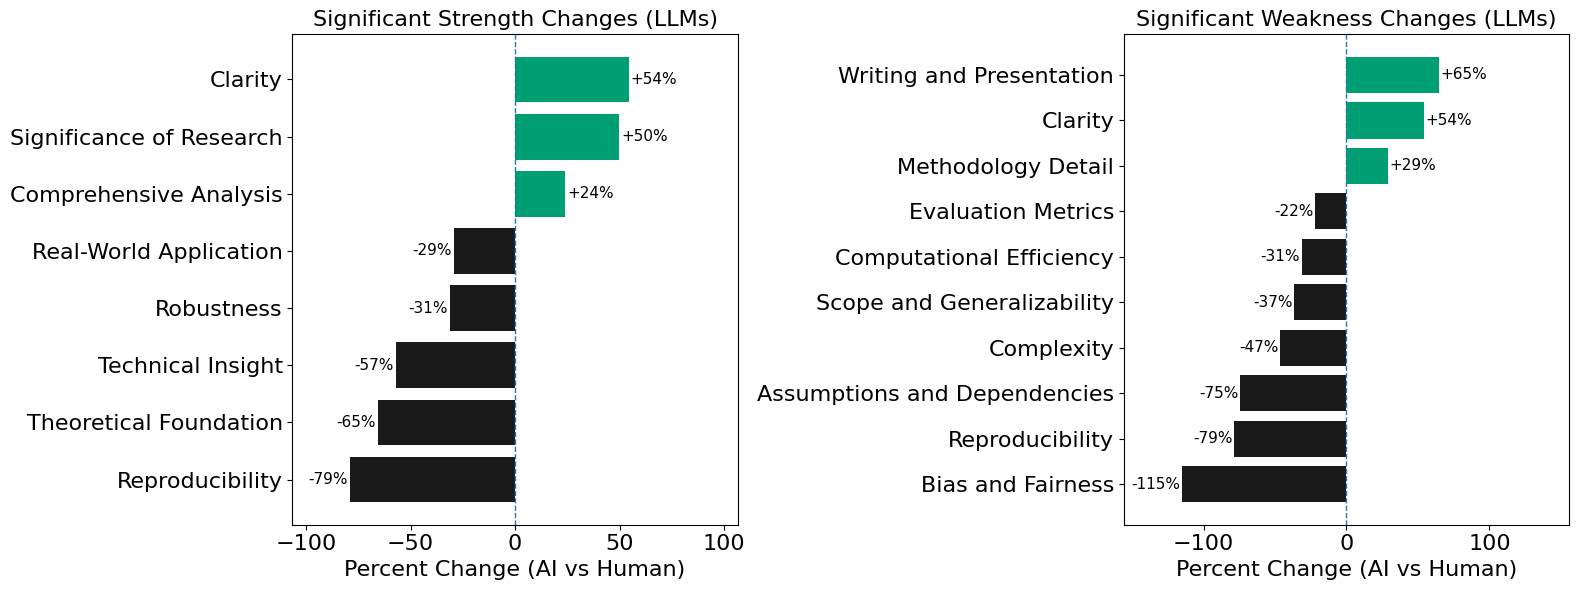

In [133]:
visualize_results(results, 'LLMs', strength_categories, weakness_categories)

,strengths,weaknesses,review_id,submission_id,type,review_text
0,"[Clarity, Novelty, Experimental Rigor]","[Baselines and Comparisons, Experimental Rigor...",qgLhRhc4hy,tuFRx6Ww2n,human,This paper proposes a method named Latent Sent...
1,"[Novelty, Comprehensive Analysis, Practical Re...","[Methodology Detail, Baselines and Comparisons...",b8RUuf49nR,KeJqoEVOeY,human,"This paper introduces CoLLMLight, the first fr..."
2,"[Experimental Rigor, Empirical Evidence, Compr...","[Clarity, Theoretical Justification, Scope and...",wKafIrVjWQ,Ybv4qufmuG,human,The paper studies RL training in LLM problems ...
3,"[Experimental Rigor, Comprehensive Analysis, E...","[Novelty, Scope and Generalizability, Methodol...",5Q5IJpsi2t,ybqL3FSOgG,human,This paper evaluates using multi-modal LLMs fo...
4,"[Novelty, Theoretical Foundation, Clarity]","[Practical Relevance, Baselines and Comparison...",US7Jar9DAl,B3Muyi2zgo,human,This paper presents eNeRgy-GPT (NRGPT) a frame...
...,...,...,...,...,...,...
2235,"[Novelty, Methodological Soundness, Comprehens...","[Assumptions and Dependencies, Scope and Gener...",fNDHvhjUIb,tysSSTIvYM,ai,"This paper introduces VALUEFLOW, a unified fra..."
2236,"[Significance of Research, Methodological Soun...","[Evaluation Metrics, Scope and Generalizabilit...",dlVUYsQmpy,2mXRhL4oPS,ai,This paper explores the use of model editing t...
2237,"[Novelty, Practical Relevance, Technical Insight]","[Methodology Detail, Writing and Presentation,...",LRELevrmkc,1JyePezdlF,ai,The paper proposes a workload-aware LLM servin...
2238,"[Significance of Research, Methodological Soun...","[Scope and Generalizability, Bias and Fairness...",KcBIZGqAuD,Y7xCdFuFw7,ai,"This paper introduces HeurekaBench, a framewor..."


In [85]:
results

,strengths,weaknesses,review_id,submission_id,type,review_text
0,"[Significance, Methodological Innovation, Eval...","[Motivation and Justification, Related Work, E...",pog1MLDFWy,jdrXx0ReH3,human,This paper evaluates LLMs on 4 esoteric progra...
1,"[Novelty, Practical Application, Methodologica...","[Related Work, Clarity, Experimental Rigor]",zwmobK6ulc,x3WyBB7Fma,human,The paper studies using LLMs and text descript...
2,"[Methodological Innovation, Novelty, Significa...","[Clarity, Presentation, Consistency]",vDEsCggzIC,3geORMaG3H,human,"The authors present ECHO-MIMIC, a two-stage co..."
3,"[Methodology Clarity, Strong Results, Evaluati...","[Experimental Rigor, Scope, Data Quality]",jIKczrbOqK,EplNy91Xqh,human,"This paper introduces SimpleTIR, a plug-and-pl..."
4,"[Methodological Innovation, Thorough Experimen...","[Presentation, Scope, Clarity]",O3yJ18x2TQ,xu1XwVZtDi,human,"In this paper, the authors propose an RL train..."
...,...,...,...,...,...,...
97,"[Methodological Innovation, Practical Applicat...","[Experimental Rigor, Clarity, Related Work]",ky0blXM1Dw,UQZ0Y0dbP9,ai,This paper proposes a novel and practical wate...
98,"[Novelty, Community Contribution, Evaluation E...","[Presentation, Methodology, Data Quality]",IBCjNFJTKL,PGZInpg1Oj,ai,"This paper introduces CodeAlignBench, a benchm..."
99,"[Practical Application, Methodological Innovat...","[Novelty, Data Quality, Scope]",GHTSlnR9c1,rp3iWs7fAS,ai,The paper ntroduces a new benchmark designed t...
100,"[Thorough Experimentation, Novelty, Significance]","[Scope, Methodology, Experimental Rigor]",cRpEV8TfmC,hrd1qQ0kf6,ai,"This paper introduces SWE-Perf, the first benc..."


In [33]:
# get possible topics from reviews_df
all_labels = reviews_df['labels'].dropna().tolist()
llms_df = reviews_df[reviews_df['labels'].str.contains('LLMs', na=False)]

In [37]:
safety_df = reviews_df[reviews_df['labels'].str.contains('safety', na=False)]

In [38]:
len(safety_df)

968

In [94]:
total_categories = ['diffusion models', 'LLMs', 'adversarial', 'RL',
       'continual learning', 'time series', 'vision-language models',
       'graphs', 'safety', 'compression',
       'autonomous driving', 'optimization', 'explainability',
       'imitation learning', 'pruning', 'multi-agent RL', 'GANs',
       'self-supervised learning', 'PDEs', 'object detection',
       'robustness', 'out-of-distribution', 'privacy', 'alignment',
       'transformers', 'clustering', 'RNNs',
       'active learning', 'semi-supervised learning',
       'federated learning', 'ViTs', '3D scenes', 'knowledge graphs',
       'autoencoders', 'causality', 'optimal transport',
       'anomaly detection', 'in-context learning', 'fairness',
       'offline RL', 'transfer learning', 'meta learning',
       'multi-task learning', 'model-based RL',
       'neural architecture search', 'speech']

In [95]:
len(total_categories)

46

In [ ]:
# for category in total_categories:
#     print(category)
#     human, ai, results, strength_categories, weakness_categories = perform_analysis_for_topic(category, reviews_df)
#     visualize_results(results, category, strength_categories, weakness_categories)
    

In [135]:
# get all unique labels 
# get the number of reviews per label
unique_labels = set(all_labels)
label_counts = {label: reviews_df['labels'].str.contains(label, na=False).sum() for label in unique_labels}
sorted_label_counts = dict(sorted(label_counts.items(), key=lambda item: item[1], reverse=True))
sorted_label_counts

{'unlabeled': np.int64(35559),
 'LLMs': np.int64(9133),
 'language models': np.int64(3811),
 'RL': np.int64(3647),
 'diffusion models': np.int64(3120),
 'graphs': np.int64(1610),
 'optimization': np.int64(1383),
 'vision-language models': np.int64(1151),
 'transformers': np.int64(1126),
 'adversarial': np.int64(972),
 'safety': np.int64(968),
 'self-supervised learning': np.int64(813),
 'time series': np.int64(793),
 'interpretability': np.int64(662),
 'alignment': np.int64(653),
 'continual learning': np.int64(635),
 'causality': np.int64(603),
 'federated learning': np.int64(589),
 '3D scenes': np.int64(587),
 'privacy': np.int64(567),
 'transfer learning': np.int64(524),
 'compression': np.int64(511),
 'in-context learning': np.int64(491),
 'multi-agent RL': np.int64(485),
 'explainability': np.int64(485),
 'code generation': np.int64(456),
 'out-of-distribution': np.int64(432),
 'robustness': np.int64(405),
 'knowledge distillation': np.int64(400),
 'PDEs': np.int64(370),
 'offline

In [ ]:
categories_to_test = []
for key in sorted_label_counts.keys():
    if key not in ['LLMs', 'RL', 'diffusion models', 'language models', 'unlabeled']:
        categories_to_test.append(key)

categories_to_test = categories_to_test[:12]
for category in categories_to_test:
    print(category)
    human, ai, results, strength_categories, weakness_categories = perform_analysis_for_topic(category, reviews_df)
    visualize_results(results, category, strength_categories, weakness_categories)

 33%|███▎      | 1/3 [00:05<00:10,  5.38s/it]

```json
{
    "strength_categories": [
        "Clarity and Organization",
        "Novel Approaches or Methods",
        "Thorough Experimental Evaluation",
        "Impactful Real-World Applications",
        "Innovative Use of Technology",
        "Contribution to Existing Literature",
        "Improved Performance or Results"
    ],
    "weakness_categories": [
        "Lack of Clarity or Motivation",
        "Insufficient Baselines or Comparisons",
        "Inadequate Experimental Detail or Analysis",
        "Data Quality Concerns",
        "Limited Scope or Generalization",
        "Reproducibility Issues",
        "Overstated Claims"
    ]
}
```


 67%|██████▋   | 2/3 [00:08<00:03,  3.94s/it]

```json
{
    "strength_categories": [
        "Novelty and Innovation",
        "Comprehensive Evaluation",
        "Clarity and Writing Quality",
        "Significant Contributions",
        "Rigorous Methodology",
        "Effective Benchmarking",
        "Detailed Analysis"
    ],
    "weakness_categories": [
        "Lack of Clarity and Definitions",
        "Insufficient Experimental Validation",
        "Limited Scope or Generalizability",
        "Questionable Validity of Claims",
        "Incomplete or Ambiguous Results",
        "Dependence on Proprietary Models",
        "Limited Novelty in Methods"
    ]
}
```


100%|██████████| 3/3 [00:11<00:00,  3.70s/it]

...

51it [01:13,  1.44s/it]



Processing AI-generated reviews...


51it [01:02,  1.22s/it]


Results saved to out_pro/strengths_weaknesses_from_automated_code generation.csv


(       submission_number submission_id  \
 2156               21642    jdrXx0ReH3   
 2606               17745    x3WyBB7Fma   
 3700               18325    3geORMaG3H   
 3758                7422    EplNy91Xqh   
 4516               22312    xu1XwVZtDi   
 5105               13699    rJv2byEWA3   
 6090               25531    62DZyNWRgv   
 8225               20581    znsrpkKqrp   
 8541               18716    3BHs9QaHYd   
 10675              13796    Dc74QT8M9i   
 13065              12526    BmkOKYfbmV   
 13171              12898    J91IKwJrqv   
 18081              21279    Wrte87s2Bs   
 18733              12870    GfPwZwZ9xZ   
 19188              15579    rV8wccsR4R   
 21742               8734    gXkIkSN2Ha   
 23001              15289    P45IBVWpLS   
 23646               2577    8m6yY1ULKh   
 24723                920    CaXZB6bI31   
 27136              20770    v3SzGCfAXN   
 29527               2371    rp3iWs7fAS   
 29720              23573    NJGBIuLfK1   
 33676     

In [ ]:
unique_labels = set(all_labels)
label_counts = {label: reviews_df['labels'].str.contains(label, na=False).sum() for label in unique_labels}
sorted_label_counts = dict(sorted(label_counts.items(), key=lambda item: item[1], reverse=True))
sorted_label_counts

In [ ]:
for key in sorted_label_counts.keys():
    if key not in ['LLMs', 'knowledge distillation', 'code generation']:
        print(key)

# Things to fix 
1. The different categories are sometimes too similar when automatically generated 
2. Get subset overlaps of the different reviews 

In [ ]:
human, ai, code_results, strength_categories, weakness_categories = perform_analysis_for_topic('RL', reviews_df)